# NR PDSCH Throughput with HARQ
This notebook demonstrates how to measure the physical downlink shared channel (PDSCH) throughput of a 5G New Radio (NR) link, as specified in the 3GPP NR standard. It is similar to the MATLAB example [NR PDSCH Throughput](https://www.mathworks.com/help/5g/ug/nr-pdsch-throughput.html) and showcases the use of the following NeoRadium features:

- Carrier and Bandwidth Part classes.
- PDSCH and DMRS objects.
- LDPC and HARQ capabilities.
- CDL channel model and extraction of channel matrix and precoding matrix.
- Resource grids, populating them, and applying channel models to them.

In [1]:
import numpy as np
import scipy.io
import time
import matplotlib.pyplot as plt

from neoradium import Carrier, PDSCH, CdlChannel, AntennaPanel, random, SnrScheduler

In [2]:
# Create a Carrier object with 52 resource blocks and 30KHz subcarrier spacing
carrier = Carrier(numRbs=52, spacing=30)
carrier.print()
bwp = carrier.curBwp                      # The only bandwidth part in the carrier


Carrier Properties:
  Cell Id:              1
  Bandwidth Parts:      1
  Active BWP:           0
  Bandwidth Part 0:
    Resource Blocks:    52 RBs starting at 0 (624 subcarriers)
    Subcarrier Spacing: 30 kHz
    CP Type:            normal
    Interleaving:       No
    Bandwidth:          18.72 MHz
    symbolsPerSlot:     14
    slotsPerSubFrame:   2
    nFFT:               1024
    frameNo:            0
    slotNo:             0



In [3]:
# Initialize the modulation and code rate.
modulation = '16QAM'
coderate = 490/1024
# Create a PDSCH onject with 2 tramsmission layers
pdsch = PDSCH(bwp, numLayers=2)
pdsch.setDMRS(configType=2, additionalPos=2)
pdsch.print()

# Creating a HarqEntity object. (It also creates an LdpcCodec object internally):
harq = pdsch.getHarq(coderates = coderate,      # Coderate(s) used by HARQ's internal LDPC codec
                     harqType = "IR",           # "IR" -> "Incremental Redundancy", "CC" -> "Chase Combining"
                     numProc = 16)              # Number of HARQ processes
harq.print()

# Create the CDL channel model
channel = CdlChannel(bwp, 'C', delaySpread=300, carrierFreq=4e9, dopplerShift=5,
                     txAntenna = AntennaPanel([1,4], polarization="x"),                     # 8 TX antennas
                     rxAntenna = AntennaPanel([1,1], polarization="+", beamWidth=[75,360]), # 2 RX antennas, Omni-directional
                     rxOrientation = [0,0,0])                                               # Default is [180,0,0]
print(channel)


PDSCH Properties:
  mappingType:               A
  nID:                       1
  rnti:                      1
  numLayers:                 2
  numCodewords:              1
  modulation:                16QAM
  PRG Size:                  Wideband
  portSet:                   0   1  
  symSet:                    0   1   2   3   4   5   6   7   8   9   10  11  12  13 
  prbSet:                    0   1   2   3   4   5   6   7   8   9   10  11  12  13  14  15  16  17  18  19 
                             20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39 
                             40  41  42  43  44  45  46  47  48  49  50  51 
  DMRS:
    configType:              2
    nIDs:                    []
    scID:                    0
    sameSeq:                 True
    symbols:                 Single
    typeA1stPos:             2
    additionalPos:           2
    cdmGroups (port:cdm):    0:0  1:0 
    deltaShifts (port:cdm):  0:0  1:0 
    numCdmGroupsWithoutD

In [4]:
# Print header lines:
print("SNR(dB)   Tx Bits     Rx Bits    Throughput(%)  TX Blocks  RX Blocks  BLER(%)  Avg. Retransmissions  time(Sec.)")
print("-------  ----------  ----------  -------------  ---------  ---------  -------  --------------------  ----------")

txBlockSizes = pdsch.getTxBlockSize(coderate)                   # Calculate the Transport Block Size (TBS)
snrScheduler = SnrScheduler(0, 1, loSnrVal=0, hiSnrVal=100, fastStep=5) # Start at 0 dB, use increments of 1 dB
numSlots = 1000                                                 # The number of slots transmitted for each SNR value
for snrDb in snrScheduler:
    random.setSeed(123)
    channel.restart()                                           # Reset the channel and the bandwidth part associated with it
    harq.reset()                                                # Reset HARQ state and buffers

    t0 = time.monotonic()                                       # Start the timer
    for s in range(numSlots):                                   # The inner loop doing 'numSlot' transmissions
        pdsch.initGrid()                                        # Create and initialize PDSCH's internal grid
        numBits = pdsch.getBitCapacity()                        # Total number of PDSCH data bits available in the resource grid

        # Preparing the transport blocks
        txBlocks = []                                           # Transport blocks, one per codeword.
        for c in range(harq.numCW):
            if harq.needNewData[c]:                             # New transmission.
                txBlocks += [ random.bits(txBlockSizes[c]) ]    # Create random bits for new transmissions
            else:                                               # Retransmission
                txBlocks += [ None ]                            # Set transport block to None to indicate a retransmission

        # The following function returns a coded, rate-matched bitstream, ready for transmission/retransmission
        rateMatchedCodeBlocks = harq.encode(txBlocks, numBits)    
        
        pdsch.setPdschData(rateMatchedCodeBlocks)               # Map/modulate the data to the resource grid
        
        channelMatrix = channel.getChannelMatrix()              # Get channel matrix (Assuming perfect channel estimation)
        precoder = pdsch.getPrecodingMatrix(channelMatrix)      # Get precoding matrix based on the channel matrix

        txGrid = bwp.createGrid(len(channel.txAntenna))         # Create the transmitted resource grid
        pdsch.precodeTo(txGrid, precoder)                       # Perform the precoding

        rxGrid = txGrid.applyChannel(channelMatrix)             # Apply the channel to the precoded resource (Freq. domain)
        noisyRxGrid = rxGrid.addNoise(snrDb=snrDb)              # Add noise

        # Calculate the effective channel matrix with the precoding effect. This is assuming perfect channel 
        # knowledge. For practical channel estimation we can use the DMRS reference signals and use the 
        # "estimateChannel" method of the PDSCH object.
        effChannelMatrix = channel.getEffChannel(channelMatrix, precoder)
        
        # Use the effective channel matrix to equalize the received resource grid
        eqGrid, llrScales = pdsch.equalize(noisyRxGrid, effChannelMatrix)

        # Demodulate the equalized resource grid (eqGrid) to get the Log-Likelihood values
        llrs = pdsch.getLLRs(eqGrid, llrScales) 

        # Use HARQ entity to decode the LLRs to transport blocks
        decodedTxBlocks, crcMatches = harq.decode(llrs)

        # Get the statistics from HARQ entity and print them:
        print(f"{snrDb:^7.2f}  {harq.totalTxBits:^10d}  {harq.totalRxBits:^10d}  {harq.throughput:^13.2f}  "
              f"{harq.totalTxBlocks:^9}  {harq.totalRxBlocks:^9d}  {harq.bler:^7.2f}  {harq.meanRetransmissions:^20.3f}  "
              f"{time.monotonic()-t0:^-10.3f}", end="\r")
        channel.goNext()
        harq.goNext()
    
    snrScheduler.setData(harq.throughput)
    print("")

SNR(dB)   Tx Bits     Rx Bits    Throughput(%)  TX Blocks  RX Blocks  BLER(%)  Avg. Retransmissions  time(Sec.)
-------  ----------  ----------  -------------  ---------  ---------  -------  --------------------  ----------
 0.00     31240000    31240000      100.00        1000       1000      0.00           0.000           442.852  
 -5.00    31240000    27834840       89.10        1000        891      10.90          0.122           429.116  
 -6.00    31240000    26210360       83.90        1000        839      16.10          0.192           420.398  
 -7.00    31240000    24960760       79.90        1000        799      20.10          0.252           416.080  
 -8.00    31240000    22930160       73.40        1000        734      26.60          0.362           406.844  
 -9.00    31240000    15776200       50.50        1000        505      49.50          0.962           370.360  
-10.00    31240000    14901480       47.70        1000        477      52.30          1.086           36

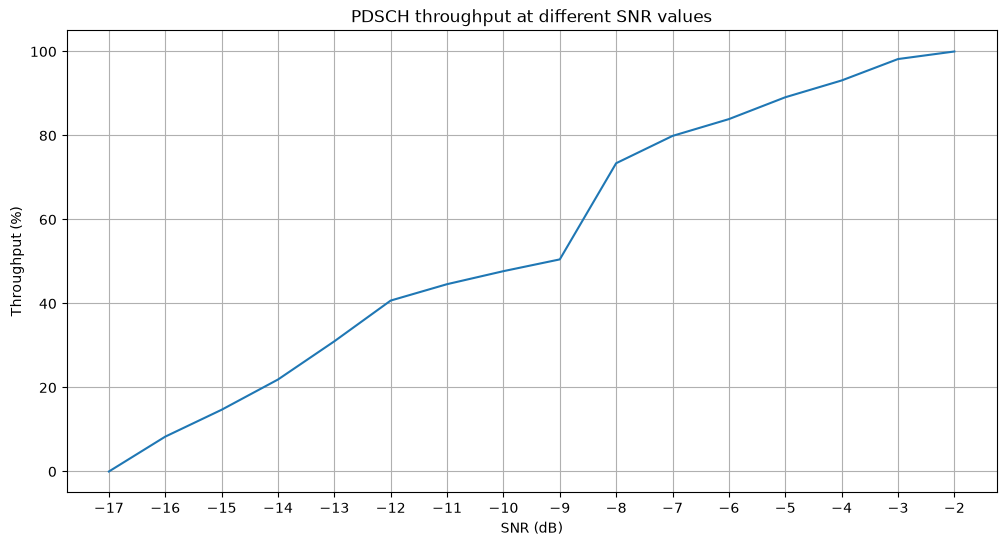

In [5]:
# Draw the throughput graph
snrDbs, throughputs = snrScheduler.getSnrsAndData()
plt.figure(figsize=(12, 6))
plt.plot(snrDbs, throughputs)
plt.title("PDSCH throughput at different SNR values");
plt.grid()
plt.xlabel("SNR (dB)")
plt.xticks(snrDbs)
plt.ylabel("Throughput (%)")
plt.show()